# Домашнее задание 2

**Цель:** Провести разведочный анализ данных, предобработку, построить три различных алгоритма кластеризации (K-Means, Agglomerative Clustering, DBSCAN), применить методы снижения размерности (PCA, t-SNE) и интерпретировать полученные профили клиентов.

### Часть 1. EDA и Preprocessing

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('data.csv')
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)
elif df.columns[0] == '' or df.columns[0].startswith('Unnamed'):
    df = df.drop(df.columns[0], axis=1)

print(f"Размерность датасета: {df.shape}")
display(df.head())
df.info()

Размерность датасета: (1000, 9)


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,NaN,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               1000 non-null   int64
 1   Sex               1000 non-null   str  
 2   Job               1000 non-null   int64
 3   Housing           1000 non-null   str  
 4   Saving accounts   817 non-null    str  
 5   Checking account  606 non-null    str  
 6   Credit amount     1000 non-null   int64
 7   Duration          1000 non-null   int64
 8   Purpose           1000 non-null   str  
dtypes: int64(4), str(5)
memory usage: 70.4 KB


Пропуски:
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
dtype: int64


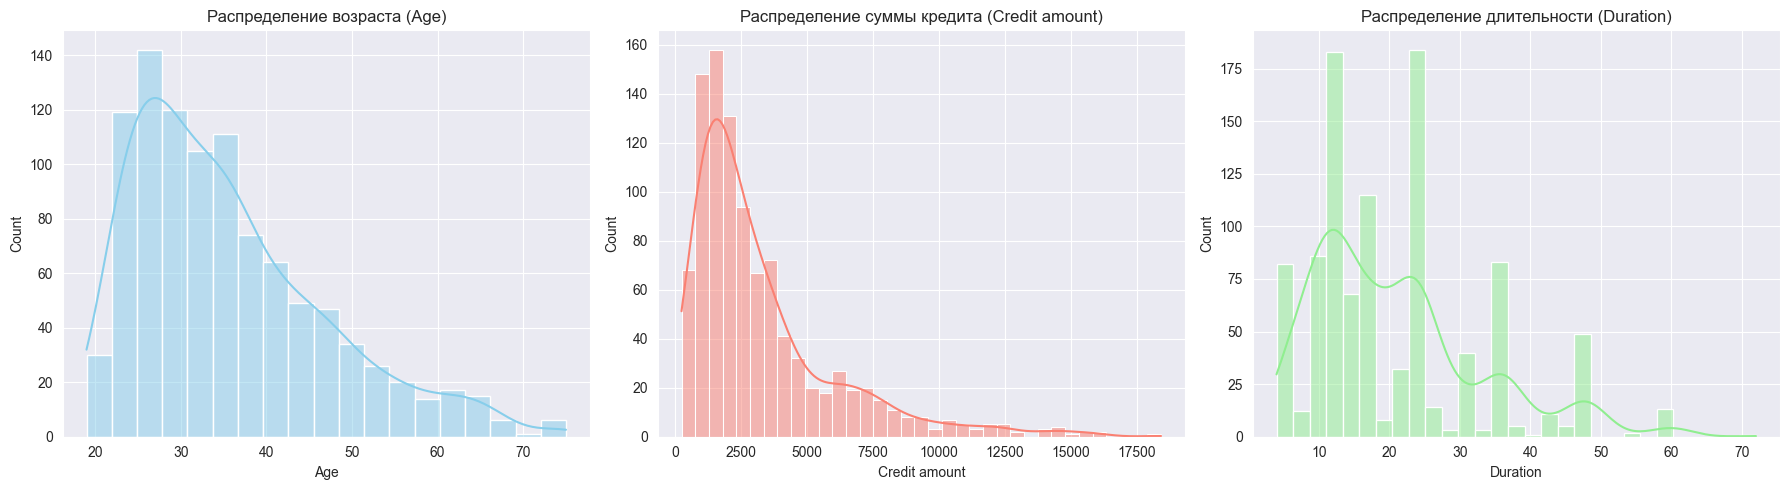

In [7]:
# Проверим пропуски
print("Пропуски:")
print(df.isna().sum())

# Заполняем пропуски отдельной категорией 'unknown', так как отсутствие информации о счете — тоже важный сигнал
df['Saving accounts'] = df['Saving accounts'].fillna('unknown')
df['Checking account'] = df['Checking account'].fillna('unknown')

# Построим распределение ключевых численных признаков
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['Age'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Распределение возраста (Age)')

sns.histplot(df['Credit amount'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Распределение суммы кредита (Credit amount)')

sns.histplot(df['Duration'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Распределение длительности (Duration)')

plt.tight_layout()
plt.show()

In [10]:
# Переводим категориальные признаки в числовые с помощью One-Hot Encoding
categorical_cols = df.select_dtypes(include=['object', 'string', 'str']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Масштабирование данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)

print(f"Размерность матрицы признаков после One-Hot Encoding и масштабирования: {X_scaled.shape}")

Размерность матрицы признаков после One-Hot Encoding и масштабирования: (1000, 21)


### Часть 2. Моделирование

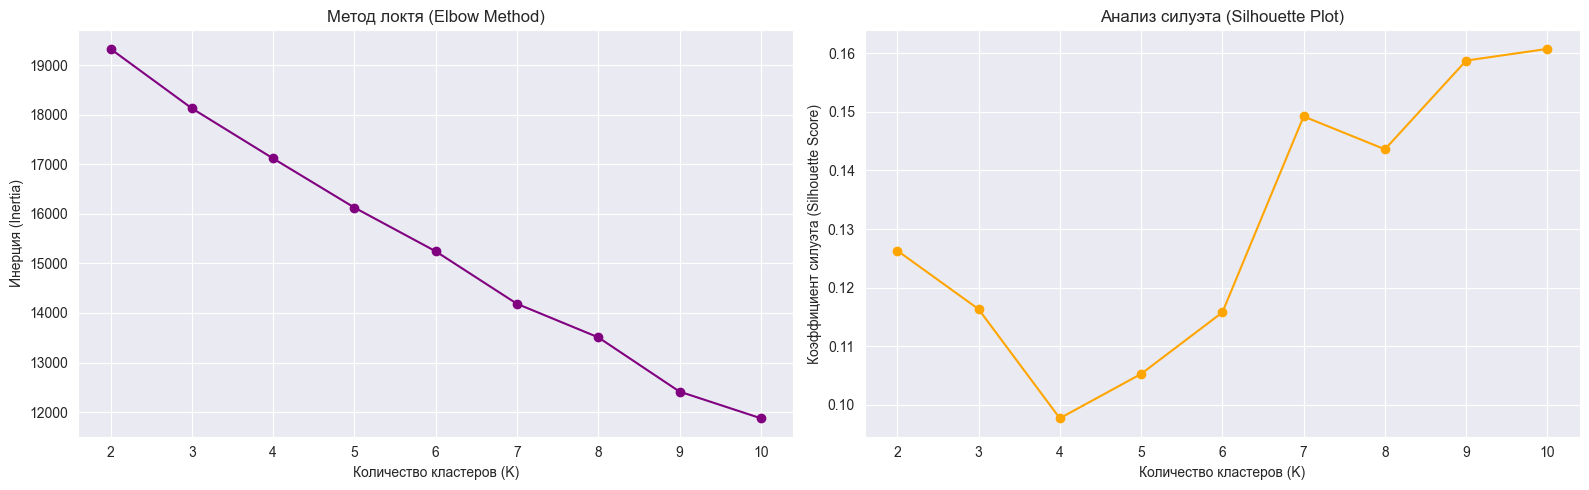

Оптимальное число кластеров на основе графиков: 3


In [11]:
# Подбор числа кластеров для K-Means с помощью метода локтя и коэффициента силуэта
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Визуализация методов выбора числа кластеров
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(K_range, inertia, marker='o', color='purple')
axes[0].set_xlabel('Количество кластеров (K)')
axes[0].set_ylabel('Инерция (Inertia)')
axes[0].set_title('Метод локтя (Elbow Method)')
axes[0].set_xticks(K_range)

axes[1].plot(K_range, silhouette_scores, marker='o', color='orange')
axes[1].set_xlabel('Количество кластеров (K)')
axes[1].set_ylabel('Коэффициент силуэта (Silhouette Score)')
axes[1].set_title('Анализ силуэта (Silhouette Plot)')
axes[1].set_xticks(K_range)

plt.tight_layout()
plt.show()

# Выбираем оптимальное K на основе баланса падения инерции и пика силуэта
best_k = 3 
print(f"Оптимальное число кластеров на основе графиков: {best_k}")

In [12]:
# Построение трех вариантов кластеризации

# 1. K-Means
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['Cluster_KMeans'] = kmeans_final.fit_predict(X_scaled)

# 2. Иерархическая кластеризация (Agglomerative)
hierarchical = AgglomerativeClustering(n_clusters=best_k)
df['Cluster_Hierarchical'] = hierarchical.fit_predict(X_scaled)

# 3. DBSCAN (подбираем eps для многомерного стандартизированного пространства)
dbscan = DBSCAN(eps=3.5, min_samples=5)
df['Cluster_DBSCAN'] = dbscan.fit_predict(X_scaled)

print("Распределение клиентов по кластерам в K-Means:")
print(df['Cluster_KMeans'].value_counts())

print("\nРаспределение клиентов по кластерам в DBSCAN (-1 — это выбросы/шум):")
print(df['Cluster_DBSCAN'].value_counts())

Распределение клиентов по кластерам в K-Means:
Cluster_KMeans
0    634
2    193
1    173
Name: count, dtype: int64

Распределение клиентов по кластерам в DBSCAN (-1 — это выбросы/шум):
Cluster_DBSCAN
 0    733
-1     85
 2     44
 4     44
 1     41
 3     34
 5     14
 6      5
Name: count, dtype: int64


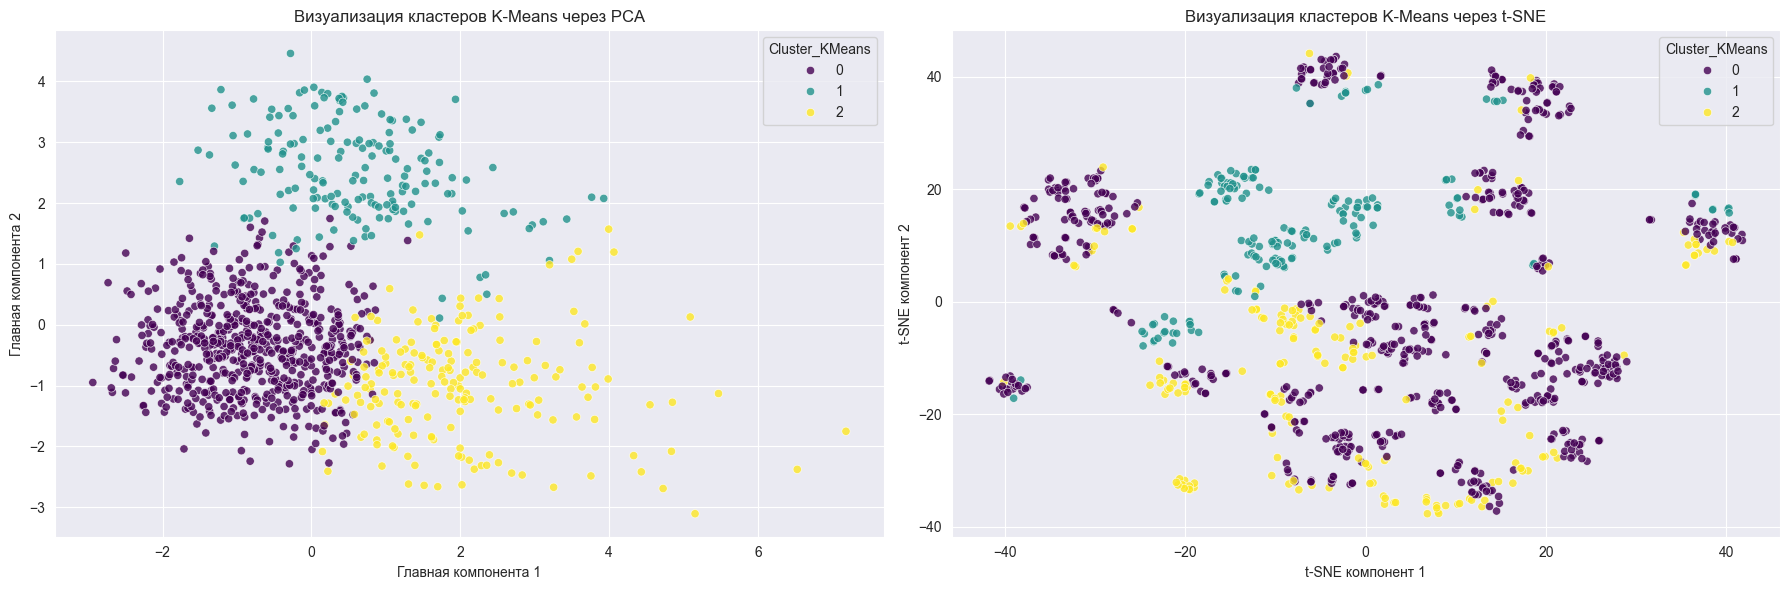

In [16]:
# Сжатие признакового пространства методами PCA и t-SNE
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

# Визуализация результатов кластеризации на плоскости
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Cluster_KMeans'], palette='viridis', ax=axes[0], alpha=0.8)
axes[0].set_title('Визуализация кластеров K-Means через PCA')
axes[0].set_xlabel('Главная компонента 1')
axes[0].set_ylabel('Главная компонента 2')

sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=df['Cluster_KMeans'], palette='viridis', ax=axes[1], alpha=0.8)
axes[1].set_title('Визуализация кластеров K-Means через t-SNE')
axes[1].set_xlabel('t-SNE компонент 1')
axes[1].set_ylabel('t-SNE компонент 2')

plt.tight_layout()
plt.show()

### Часть 3. Интерпретация результатов

In [18]:
# Расчет средних значений числовых признаков
numerical_features = ['Age', 'Credit amount', 'Duration', 'Job']
print("Средние значения числовых признаков по кластерам:")
display(df.groupby('Cluster_KMeans')[numerical_features].mean().round(2))

# Модальные значения для категориальных признаков
categorical_features = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
print("Самые частые категории по кластерам:")
display(df.groupby('Cluster_KMeans')[categorical_features].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan))

Средние значения числовых признаков по кластерам:


,Age,Credit amount,Duration,Job
Cluster_KMeans,,,,
0,36.53,2162.86,16.80,1.80
1,30.16,2865.74,18.35,1.83
2,37.16,7275.81,36.67,2.31


Самые частые категории по кластерам:


,Sex,Housing,Saving accounts,Checking account,Purpose
Cluster_KMeans,,,,,
0,male,own,little,unknown,radio/TV
1,female,rent,little,little,car
2,male,own,little,moderate,car


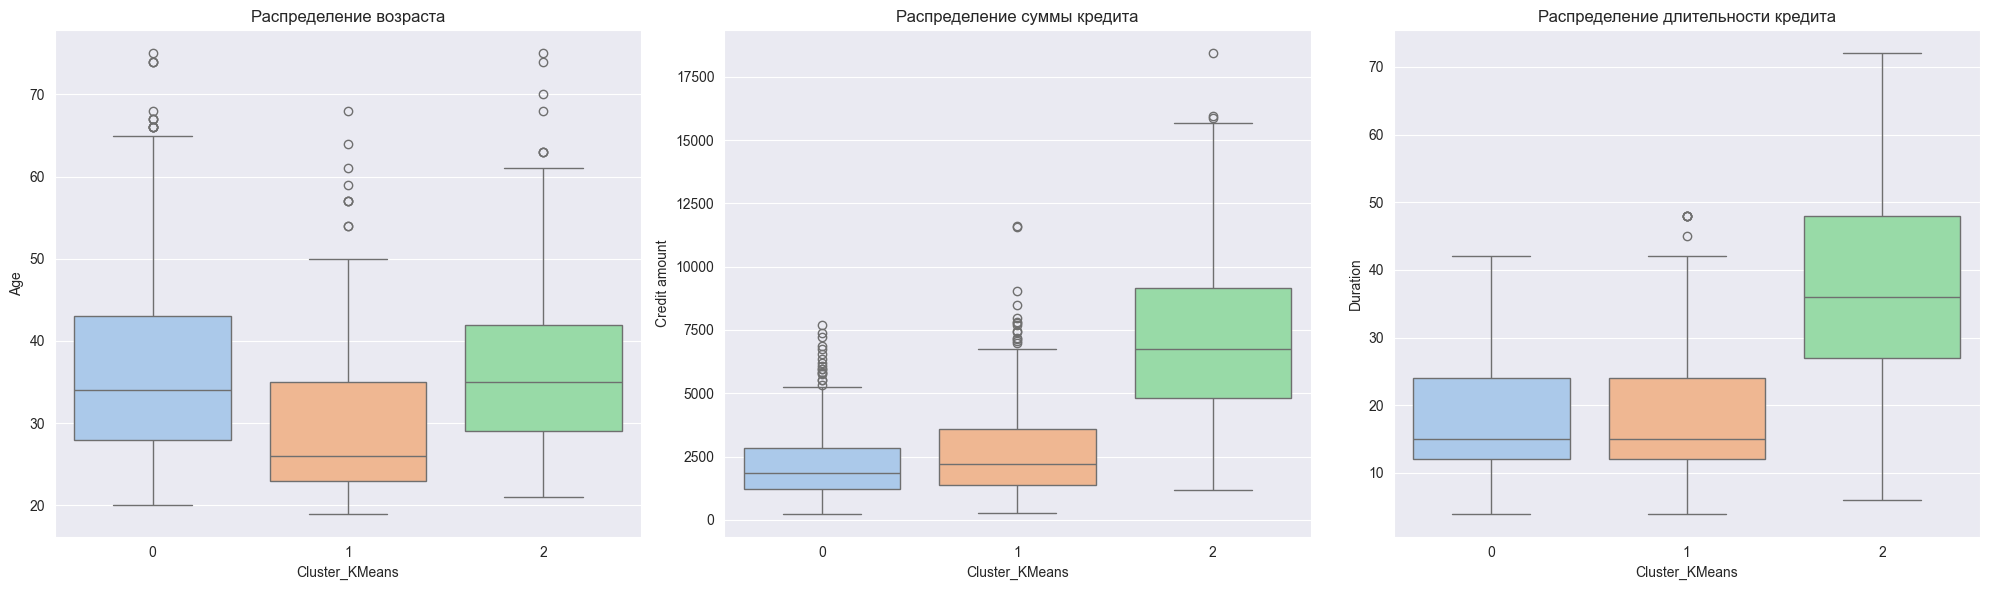

In [19]:
# Построение boxplot-ов для визуального анализа различий между кластерами
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.boxplot(data=df, x='Cluster_KMeans', y='Age', ax=axes[0], hue='Cluster_KMeans', palette='pastel', legend=False)
axes[0].set_title('Распределение возраста')

sns.boxplot(data=df, x='Cluster_KMeans', y='Credit amount', ax=axes[1], hue='Cluster_KMeans', palette='pastel', legend=False)
axes[1].set_title('Распределение суммы кредита')

sns.boxplot(data=df, x='Cluster_KMeans', y='Duration', ax=axes[2], hue='Cluster_KMeans', palette='pastel', legend=False)
axes[2].set_title('Распределение длительности кредита')

plt.tight_layout()
plt.show()

### Выводы:

В ходе исследования аудитория немецкого банка была разделена алгоритмом K-Means на 3 четких бизнес-сегмента (выбор подтвержден локальным пиком метода Силуэта при K=3):

1. Кластер 0 — Благополучные потребители (634 чел.):
Самый массовый сегмент. Мужчины среднего возраста (36.5 лет) со своим жильем. Берут минимальные суммы (2.1k) на короткий срок (17 мес.) в основном на покупку электроники и бытовой техники (radio/TV). Наиболее стабильная и низкорисковая группа.
2. Кластер 1 — Умеренный риск (173 чел.):
Самый молодой сегмент (30.1 лет). Полностью состоит из женщин, которые чаще всего арендуют жилье (rent) и имеют небольшие накоплениz. Берут средние суммы (2.8k) преимущественно на покупку автомобиля (car).
3. Кластер 2 — Высокорисковые крупные заемщики (193 чел.):
Клиенты с самым высоким профессиональным статусом (37.1 лет). Запрашивают большие суммы (7.2k) на длительные сроки (37 мес.) для покупки авто (car) и на бизнес. Сегмент генерирует максимальный доход для банка, но требует жесткого скоринга из-за высоких рисков.

**Вывод по методам и визуализации:**
* DBSCAN не подошел для этой задачи, так как из-за разреженности данных после One-Hot Encoding объединил почти всех клиентов в один мега-кластер (733 человека), выделив 85 в шум.
* Нелинейный метод t-SNE показал себя гораздо эффективнее линейного PCA. На графике t-SNE отчетливо видны изолированные «островки» клиентов, на которые идеально легли кластеры K-Means. Это доказывает сложную нелинейную структуру связей между анкетой клиента и его финансовым поведением.
